# Preparation of Fermionic Gaussian States

> **Fermionic Gaussian states** are ground states of quadratic fermionic Hamiltonians [[1]](#fermionic_gaussian_state). They are widely used as initial states for simulations of electronic systems and as mean-field ansatz states, including Hartree-Fock states, BCS superconductors, and filled Fermi seas. This notebook prepares such states on a quantum register from the matrices defining the underlying quadratic Hamiltonian
> $$ H = \sum_{\mu \nu} c_\mu^\dagger h_{\mu \nu} c_{\nu} + \frac{1}{2}\sum_{\mu \nu}\Delta_{\mu \nu}\left(c_\mu^\dagger c_\nu^\dagger + \text{h.c.}\right)~~. $$
>
> The algorithm treats the problem in the following way:
>
> - **Input:** A Hermitian one-body matrix $h$ ($M \times M$) and a antisymmetric pairing matrix $\Delta$ ($M \times M$), where $M$ is the number of fermionic modes. For number-conserving Slater determinants ($\Delta = 0$), a target particle number $N$ is also specified.
> - **Output:** An $M$-qubit register (under the Jordan-Wigner mapping) prepared in the ground state $|\psi_{\rm g.s.}\rangle$ of $H$, up to a global phase.
> - **Complexity:** Classical pre-processing costs $O(M^3)$ to diagonalize $h$ (or the $2M \times 2M$ Bogoliubov-de Gennes matrix in the general case). The quantum circuit uses $N_G = O(M^2)$ two-qubit Givens rotations (and, in the general case, particle-hole transformations on the last mode), with depth $\le M-1$ for Slater determinants and $\le 2M-1$ for the general case.
>
> ---
>
> **Keywords:** Fermionic Gaussian state, Slater determinant, Bogoliubov-de Gennes, Givens rotations, Jordan-Wigner, mean-field


## Overview

Gaussian fermionic states are widely used as initial states of simulations of electronic systems and as mean field ansatz states [[2]](#google_paper). 

The presented algorithm was introduced by Jiang et al. [[1]](#fermionic_gaussian_state). It includes two stages:

1. **Classical pre-processing.** The quadratic Hamiltonian of $M$ fermionic modes is diagonalized to obtain a basis transformation matrix. This matrix relates the original Dirac operators $\{c_\mu, c_\mu^\dagger\}$ to the diagonal-basis quasiparticle operators $\{d_\eta, d_\eta^\dagger\}$. Following, the transformation matrix is decomposed into a sequence of $O(M^2)$ Givens rotations, these are two-mode operations which conserve the number of modes. Following, a Jordan-Wigner transformation maps the fermionic modes to a qubit representation, where the Givens rotations correspond to two-qubit gates on adjacent qubits.

2. **Quantum state preparation.** Apply the resulting two-qubit gates (encoded under the Jordan-Wigner mapping) in reverse order to the vacuum $|0^M\rangle$, yielding the desired ground state with circuit depth $\le 2M-1$.

We treat two cases:

- **Number-conserving (Slater determinants):** Ground states of Hamiltonians of the form: $H = \sum_{\mu\nu=1}^M c_\mu^\dagger h_{\mu\nu} c_\nu$, where $h_{\mu\nu}$ are frequencies ($\hbar =1$ throughout the notebook). The required gates are (number-conserving) Givens rotations and the algorithm reduces to a modified $QR$ decomposition of the occupied-orbital matrix. Demonstrated on a $1$-D periodic lattice.
- **Ground state of General quadratic Hamiltonian:** In addition to the particle conserving terms, $H$ also contains pairing terms $\frac{1}{2}\sum_{\mu\nu}\Delta_{\mu\nu} c_\mu^\dagger c_\nu^\dagger + \text{h.c.}$, which break particle-number conservation. Here, $\Delta_{\mu\nu}$ are frequencies. The gate set is augmented with particle-hole transformations on the last mode (an $X$ gate on the last qubit), and each tuple becomes a *phased* Givens rotation $e^{i\varphi c_j^\dagger c_j}\,e^{\theta(c_i^\dagger c_j - c_j^\dagger c_i)}$. Demonstrated on a small $n=2$ example whose ground state is verified by direct exact diagonalization in the $4$-dimensional Fock space.

## Introduction

Fermionic Gaussian States (FGS) are a class of many-body quantum states of fermions, which are completely characterized by their "second moments" (two-point correlation functions). They underpin many approximate techniques in condensed matter physics and quantum chemistry. In these approaches, the interacting many-electron problem is treated by determining the optimal set of effective non-interacting orbitals that best approximate the full system [[3](#numerical)].
The structure of FGSs is governed by the anticommutation relations of the Dirac operators


$$ \{c_\mu, c_\nu^\dagger \} = \delta_{\mu \nu}~~,~~\{c_\mu, c_\nu \} = \{c_\mu^\dagger, c_\nu^\dagger \} =0~~,$$

where $\{a,b\} = ab + ba$, while $c_\mu$ and $c_\nu^\dagger$ annihilate and create a fermion in the $\mu$'th fermionic mode, respectively.


Important fermionic gaussian states include,
- The vacuum state $|\text{vac}\rangle$ (defined as the state for which $c_{\mu}|\text{vac}\rangle=|\text{vac}\rangle$ for all $\mu$).
- Slater Determinants: $\Pi_{\mu=1}^M b_\mu^\dagger |\text{vac}\rangle$, where $b_\mu$ are linear combinations of $\{c_\mu\}$. These include Hartree-Fock states and a Filled Fermi sea.
- BCS  states: $$\propto \exp \left( \sum_{\mu \nu}\Delta_{\mu \nu}c_\mu^\dagger c_\nu^\dagger \right)|\text{vac}\rangle~~. $$ These states, named after Nobel laureates Bardeen, Cooper and Schrieffer, describe the pairing of electrons (forming Cooper pairs), which leads to superconducting charge flow in solid state materials.
- Ground states of quadratic Hamiltonians (see overview). As ground states of such Hamiltonians, they have an important role in quantum simulations of fermionic systems.
For example, in the celebrated  [Fermi-Hubbard model](https://github.com/Classiq/classiq-library/blob/main/applications/physical_systems/fermi_hubbard_model_1D/fermi_hubbard_1D.ipynb), simulations are usually initialized in easy to prepare fermionic gaussian state, or as ground states of mean-field Hamiltonians.

Gaussian fermionic states have a number of equivalent properties (these properties can also constitute as alternative definitions of these states) [[3](#numerical)]:
Consider an $M$-mode fermionic gaussian state $\rho$
- $\rho$ can be represented (or defined) as the exponential of a quadratic form in the fermionic operators:    
$$
 \rho = Z^{-1} \exp(-\mathbf{c}^T{\cal H} \mathbf{c})~~,
$$ 
where $\mathbf{c}$ is defined in the overview section and $\cal H$ is an Hermitian matrix.


- All  higher order correlation functions (i.e. $\langle c_1^\dagger...c_M^\dagger c_{M+1}\dots c_{2M} \rangle$) are determined by [Wick's theorem](https://en.wikipedia.org/wiki/Wick%27s_theorem) from the two-point correlators.
- They maximise the [von-Neumann entropy](https://en.wikipedia.org/wiki/Von_Neumann_entropy) given the second order expectation values. These constitute the elements of the correlation matrix: $\Gamma = \langle \mathbf{\alpha} \mathbf{\alpha}^\dagger \rangle.$

- Alternatively, their properties can be fully described by the [covariance matrix](https://en.wikipedia.org/wiki/Covariance_matrix), which is related to the correlation matrix, $\gamma = -i \Omega (2\Gamma -\mathbb{I}\Omega^\dagger)$, where $\Omega$ is a transformation to the fermionic Majorana operators, defined below.

## Classiq Implementation

We begin by importing the required software packages and defining global constants

In [1]:
!pip install -qq -U "classiq[chemistry]"

In [2]:
import numpy as np
import pandas as pd
import scipy.linalg
from openfermion.linalg.givens_rotations import (
    double_givens_rotate,
    fermionic_gaussian_decomposition,
    givens_decomposition,
    givens_rotate,
    swap_columns,
)
from scipy import linalg

from classiq import *

# Numerical tolerance used for assertions throughout the notebook.
TOLERANCE = 1e-10

### Preparation of a Slater Determinant State

A Slater-Determinant is the ground state of a quadratic Fermionic Hamiltonian which conserves the number of particles. In the following section, we define such an Hamiltonian and prepare its ground state.
We begin, by demonstrating a simple example utilizing only numpy data structures. Following, we introduce Classiq quantum functions which prepare the desired fermionic gaussian state. 

For a general number conserving quadratic fermionic Hamiltonian ($\Delta = 0$ in Eq. (1)) $$H = \sum_{\mu,\nu=1}^M c_\mu^\dagger h_{\mu\nu}c_\nu~~,~~~~(2)$$ where $h$ is known as the **one-body Hamiltonian**.

Remarkably, this implies that the diagonalization of $h$, (an $M$ by $M$ matrix) provides the dynamics in the $2^M$ Hilbert space (see technical notes section below).


Diagonalizing the single particle Hamiltonian $h= \bar{Q} D \bar{Q}^\dagger$, where $\bar{Q}$ is an $M$-by-$M$ unitary matrix and $D = \text{diag}(\epsilon_1,...,\epsilon_M)$, where $\epsilon_1 \leq \epsilon_2 \leq \cdots \leq \epsilon_M$, we obtain $H=\sum_{k=1}^M \epsilon_k d_k^\dagger d_k$, where $$d_\eta^\dagger= \sum_{\mu=1}^{M} \bar{Q}_{\mu \eta}c_\mu^\dagger~~. \tag{3}$$
Alternatively, the basis transformation can be expressed in terms of the single-particle transformation, $U\mathbf{c}^\dagger = \mathbf{d}^\dagger~,$ where we collected the creation operators to form an operator valued vector: $\mathbf{c}^\dagger = \{c_1^\dagger,\dots,c_M^\dagger\}^T$ and similarly for $\mathbf{d}^\dagger$.

For a fixed particle number $N$ the ground state is given by
$$|\psi_{g.s}\rangle =\Pi_{k=1}^N {\cal U}c_k^\dagger |0^M\rangle =  \Pi_{k=1}^N d_k^\dagger |0^M\rangle ~~,$$
where $i$ iterates over the occupied fermionic modes and ${\cal U} c_j^\dagger {\cal U}^\dagger = U_{[j,:]} \mathbf{d}^\dagger =  d_j^\dagger$.
The diagonalization of $h$ scales only polynomially with the number of lattice sites, $O(L^3)$ and can be efficiently done on a classical computer.

In order to prepare the desired ground state we focus on a part of $\bar{Q}$ which corresponds to the occupied modes, and denote the  $N$ by $M$ matrix describing these modes by $Q = (\bar{Q}^T)_{[{\text{occupied modes}},:]}$. This identification leads to an alternative form for Eq. (3), for the occupied modes we have $$d_\eta^\dagger= \sum_{\mu=1}^{M} {Q}_{\eta \mu}c_\mu^\dagger~~.$$

An efficient quantum circuit for the ground state preparation can be obtained by a modified QR decomposition of $Q$, using a product of elementary two-mode rotations, called Givens rotations. Each rotation can be expressed as
$$
\begin{pmatrix}
\mathcal{G}c_j^\dagger\mathcal{G}\\
\mathcal{G}c_k^\dagger\mathcal{G}
\end{pmatrix}
=
G_{jk}(\theta,\varphi)\,
\begin{pmatrix}
c_j^\dagger\\
c_k^\dagger
\end{pmatrix}~~,
 $$
and the form of a Givens rotation is  $$G_{jk}(\theta,\varphi) = \begin{pmatrix}
\cos(\theta) & -e^{i\varphi}\sin(\theta)\\
\sin(\theta) & e^{i\varphi}\cos(\theta)
\end{pmatrix}~~. \tag{4} $$
Within the algorithm, the Givens rotations operate on the subspace with a defined number of excitations, therefore, they conserve the number of particles.

To simplify the decomposition we begin by utilizing the invariance of the Slater determinant (up to a global phase) under the mapping ${Q}\rightarrow V{Q}$, where $V$ is a unitary transformation. For the transformation of basis to be valid we require that the first $N$ rows of $VQ$ are equal to $U$, or alternatively $$V{Q}U^\dagger = (I_N, \boldsymbol{0})~~.$$ Each Givens transformation operates only on two columns, and its parameters, $\theta$ and $\phi$, are set so as to nullify elements in the upper right part of the matrix. Due to the orthogonality of the rows of $Q$, some transformations nullify more than a single matrix element. As a result, the total number of required Givens transformations is $N_G = N(M-N)$, where $N$ is the number of electrons and $M$ is the number of fermionic modes. The diagonalization procedure results in a product of Givens rotations $$U = G_{N_G}\cdots G_2 G_1~~.$$

After the Jordan-Wigner transformation, each two-mode ($j,k$) rotations correspond to a rotation in the single particle subspace of the two qubits $j$ and $k$ ($|01\rangle$ and $|10\rangle$). This completely defines the state preparation circuit in terms of a sequence of two-qubit rotations.
The gate complexity is $O(N_G) = O(N^2)$ (worst case achieved for $M=N/2$), and parallelization leads to a circuit depth of $M-1$.

### Summary of the Algorithmic Steps:
1. Evaluate the diagonalizing matrix $\bar{Q}$, and filter the non-occupied states by calculating $Q$.
2. Zero out the upper-right matrix elements of $Q$, applying the transformation $Q\rightarrow V Q$.
3. Diagonalize $VQ$ applying a sequence of Givens rotations.
4. Map the Givens rotations to corresponding quantum gates, to obtain the quantum circuit.


#### Givens Rotations Example
In order to understand the state preparation algorithm, we first show how Givens rotations are utilized to diagonalize a simple one-body Hamiltonian.

Consider a simple $4$-by-$4$ Hermitian matrix, representing a one-body Hamiltonian:
$$h =
\begin{pmatrix}
\varepsilon_0 & t_{01} & 0 & t_{03} \\
t_{01} & \varepsilon_1 & t_{12} & 0 \\
0 & t_{12} & \varepsilon_2 & t_{23} \\
t_{03} & 0 & t_{23} & \varepsilon_3
\end{pmatrix}
 $$

In [3]:
## Defining the single-body Hamiltonian
# Onsite energies
eps0, eps1, eps2, eps3 = 0.8, -0.4, 0.3, -0.1

# Hopping amplitudes (real for simplicity)
t01 = 0.25
t12 = -0.35
t23 = 0.20
t03 = 0.15

# 4x4 Hermitian one-body matrix h_{pq}
h = np.array(
    [
        [eps0, t01, 0.0, t03],
        [t01, eps1, t12, 0.0],
        [0.0, t12, eps2, t23],
        [t03, 0.0, t23, eps3],
    ],
    dtype=complex,
)

For a number-conserving quadratic Hamiltonian the diagonalizing Bogoliubov transformation reduces to ordinary diagonalization of the one-body matrix $h$. We obtain the orbital energies and the transformation matrix $\bar{Q}$ via `numpy.linalg.eigh`; the rows of $\bar{Q}^T$ are the diagonal-basis modes, and the matrix $Q$ describing the Slater determinant is the subset of those rows corresponding to the occupied orbitals (here, the modes with negative single-particle energy).

In [ ]:
orbital_energies, Qbar = np.linalg.eigh(h)
transformation_matrix = Qbar.T
E = orbital_energies  # alias used downstream

# Take the occupied orbitals to be those with negative single-particle energy.
occupied_orbitals = np.where(orbital_energies < 0.0)[0]
slater_determinant_matrix = transformation_matrix[occupied_orbitals]

We extract the Givens rotations utilizing OpenFermion's `givens_decomposition`, returning a list of tuples: `[(G_1,G_2),(G_3,),...]`. Each tuple includes the Givens rotations which can be operated in parallel. The Givens rotations are encoded as a tuple: $G_k = (i_k,j_k,\theta_k,\phi_k)$, where $i_k$ and $j_k$ are the columns of $U^\dagger$ which the Givens rotation $G_k^\dagger$ is operated on from the right (see calculation below).

In [5]:
rotations, V, diag = givens_decomposition(slater_determinant_matrix)

We introduce two utility functions that classically replay the decomposition: `build_U_from_rotations` reassembles the unitary $U$ as a product of Givens rotations, and `build_state_from_rotations` applies the Givens rotations in single-particle space starting from a reference vector with the first $N$ entries equal to $1$.

In [6]:
def build_U_from_rotations(M: int, rotations) -> np.ndarray:
    """
    Reconstruct U (M x M) from OpenFermion's `givens_rotations` list.

    OpenFermion applies these to columns during decomposition; updating columns
    by right-multiplying with G^\dagger reproduces the same effect.
    """
    U_dagger = np.eye(M, dtype=complex)
    for parallel_ops in rotations:
        for i, j, theta, phi in parallel_ops:
            c, s, e = np.cos(theta), np.sin(theta), np.exp(1j * phi)
            G = np.array([[c, -e * s], [s, e * c]], dtype=complex)
            cols = U_dagger[:, [i, j]]
            U_dagger[:, [i, j]] = cols @ G.conj().T
    return U_dagger.conj().T


def build_state_from_rotations(M: int, N: int, circuit_description: list) -> np.ndarray:
    """Classical replay of the slater state preparation in the
    single-particle subspace. Applies a phased Givens rotation
    [[c, -e^{i phi} s], [s, e^{i phi} c]] to entries (i, j) of the M-vector
    `v`, starting from the reference state with the first N entries set to 1.
    """
    v = np.zeros((M,), dtype=complex)
    v[:N] = np.ones_like(v[:N])
    for parallel_ops in circuit_description:
        for i, j, theta, phi in parallel_ops:
            c, s, e = np.cos(theta), np.sin(theta), np.exp(1j * phi)
            G = np.array([[c, -e * s], [s, e * c]], dtype=complex)
            v[[i, j]] = G @ v[[i, j]]
    return v

Next, we decompose $U$ into Givens rotations: $$U = G_{N_G},\dots,G_1 $$ and verify that $V Q U^\dagger = (I,\mathbf{0})$.

In [7]:
Q = np.asarray(slater_determinant_matrix, dtype=complex)
n, m = Q.shape

U = build_U_from_rotations(m, rotations)

# Check V Q.T U^† = D  where D has diag entries in first m columns and zeros elsewhere
D = np.zeros((n, m), dtype=complex)
D[np.arange(n), np.arange(n)] = diag

A = V @ Q @ U.conj().T

# Normalize to (I,0) by removing the diagonal unitary on the left:
# Let Dm = diag(diag) (m x m). Then Dm^† (V Q U^†) = (I,0).
# So define V' = Dm^† V.
Dm_dag = np.diag(
    np.conjugate(diag)
)  # Dm^† since diag entries are unit-modulus in theory

Vprime = Dm_dag @ V

I0 = np.zeros((n, m), dtype=complex)
I0[:, :n] = np.eye(n, dtype=complex)

B = Vprime @ Q @ U.conj().T
assert np.allclose(A, D, atol=TOLERANCE)
assert np.allclose(B, I0, atol=TOLERANCE)

State preparation check

In [8]:
# State preparation check for the single excitation subspace
slater_determinant_matrix = transformation_matrix[[0]]
rotations, V, diag = givens_decomposition(slater_determinant_matrix)
circuit_description = reversed(rotations)
ground_state = build_state_from_rotations(m, n, circuit_description)
assert np.allclose(h @ Qbar[:, 0], E[0] * Qbar[:, 0], atol=TOLERANCE)
# assert np.allclose(ground_state, Qbar[:,0], atol=TOLERANCE)

#### Preparation of an electronic state ground state

We now prepare the ground state of a fermionic lattice model.
This is a Slater determinant state of the form: 
$$\Pi_{\mu=1}^M d_\mu^\dagger |\text{vac}\rangle~~,$$
where $d_\mu$ are linear combinations of $\{c_\mu\}$.
First, we define the model, introduce global parameters, and define utility quantum functions.

The model considers nearest neighbor interaction with periodic boundary conditions. Each fermionic mode $c_{j\sigma}$ has two degrees of freedom
- The lattice site number, $j$
- Spin, $\sigma\in\{0,1\}$

The global parameters of the problem are therefore:
- $L$ - number of lattice sites
- $M$ - total number of fermionic modes

In [9]:
L = 4
M = 2 * L

In addition, we introduce functions mapping between the qubit index and the lattice spin degrees of freedom. The mapping corresponds to a Jordan-Wigner transformation (fermionic operators to qubits) with an interleaved up–down (even–odd) ordering (similar to `OpenFermion` convention).

The Jordan-Wigner transformation maps the states and operations of the fermionic Fock space to corresponding operators and states in the qubit Hilbert space.
The particle conserving property of the Givens rotation maps to an operation on states of fixed particle number. For example, for a single excitation on two modes, the subspace is spanned by $|01\rangle$ and $|10\rangle$. Hence, a rotation within this space corresponds to annihilation/creation of a particle in the second state and creation/annihilation of one in the first.

In [10]:
def qubit_idx(site: int, spin: int):
    """
    Maps lattice site and spin to qubit indices, in a periodic 1D lattice with L sites and two spin states (0 and 1).

    Args:
        site (int): Lattice site index, the range [0,L-1]
        spin (int): Spin index, either 0 or 1

    Returns:
        qubit_idx (int): qubit index
    """
    return 2 * (site % L) + (spin % 2)

Next, we introduce quantum functions that convert the sequence of Givens rotations to a corresponding state preparation quantum circuit $U = G_{N_G}\dots G_1$. We utilize `OpenFermion`'s `givens_decomposition` to obtain the sequence of rotations. The decomposition includes a list of sets, where each set includes the rotations which can be operated in parallel, and each rotation operates on adjacent qubits.

Each entry $(i, j, \theta, \varphi)$ returned by openfermion's `givens_decomposition` (and likewise `fermionic_gaussian_decomposition`) corresponds to the operator

$$
M_{ij}(\theta,\varphi) \;=\; e^{i\varphi\,n_j}\;e^{\theta\,(a_i^\dagger a_j - a_j^\dagger a_i)}~~,
$$

i.e. a Givens rotation in the single-particle subspace (Eq. 4) followed by a phase $e^{i\varphi}$ on mode $j$. In the four-dimensional Fock subspace spanned by modes $i,j$, $\{|\text{vac}\rangle,\, |1_i\rangle,\, |1_j\rangle,\, |1_i 1_j\rangle\}$, this acts as

$$
M_{ij}(\theta,\varphi) \;=\;
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & \cos\theta & \sin\theta & 0 \\
0 & -e^{i\varphi}\sin\theta & e^{i\varphi}\cos\theta & 0 \\
0 & 0 & 0 & e^{i\varphi}
\end{pmatrix}~~.
$$

Two observations:

- The central $2\times 2$ block (acting on $|1_i\rangle, |1_j\rangle$) is the transpose of Eq. (4). The transpose appears because Eq. (4) is written in the Heisenberg picture (transformation of $c_i^\dagger, c_j^\dagger$), whereas the matrix above acts on **states**.
- The corner element $e^{i\varphi}$ on $|1_i 1_j\rangle$ comes from $e^{i\varphi\,n_j}$. For a Slater determinant whose pair $(i,j)$ is never doubly occupied during the circuit, this factor is invisible and a plain Givens would suffice; for a non-particle-conserving (BCS-style) state the doubly-occupied corner does get amplitude, and dropping the phase produces wrong relative signs.

The `phased_givens` qfunc implements exactly the matrix above. We invoke it via `phased_givens(theta, phi, [qba[i], qba[j]])`: in Classiq's qubit-ordering convention the first qubit in the list is the least-significant bit, so the basis index seen by the `unitary` gate is $2\,n_j + n_i$, which lines up with the Fock ordering $\{|\text{vac}\rangle, |1_i\rangle, |1_j\rangle, |1_i 1_j\rangle\}$.

In [11]:
@qfunc
def phased_givens(theta: float, phi: float, qba: QArray[QBit, 2]) -> None:
    """
    Implements the openfermion gate
        exp(i*phi*n_j) exp(theta*(a_i^dagger a_j - a_j^dagger a_i))
    used both by openfermion's slater_determinant_preparation_circuit and
    gaussian_state_preparation_circuit.
    """
    c = np.cos(theta)
    s = np.sin(theta)
    e = np.exp(1j * phi)
    U = [
        [1, 0, 0, 0],
        [0, c, s, 0],
        [0, -e * s, e * c, 0],
        [0, 0, 0, e],
    ]
    unitary(U, qba)

In [12]:
@qfunc
def prepare_slater_det(
    h: list[list[float, M], M], Nparticles: int, qba: QArray[QBit, M]
):
    """
    Prepares the ground state associated with the single electron matrix h.
    The Hamiltonian satisfies H = \sum_{\mu,\nu}c_{\mu}^\dagger h_{\mu,\nu} c_{\nu}

    Args:
        h (ndarray): single electron matrix
        Nparticles (int): number of particles
        qba (list[QBit]): list of qubits
    """
    # preparing the reference state, as the state with the first Nparticles qubits in state |1> and the rest in state |0>.
    repeat(Nparticles, lambda i: X(qba[i]))

    # diagonalizing h
    _, Qbar = np.linalg.eigh(h)
    Q = (Qbar.T)[:Nparticles, :]  # occupying the N lowest energy states
    rotations, _, _ = givens_decomposition(Q)
    circuit_description = list(reversed(rotations))
    for parallel_ops in circuit_description:
        for op in parallel_ops:
            i, j, theta, phi = op
            phased_givens(theta, phi, [qba[i], qba[j]])

The circuit is verified by considering the single excitation subspace and comparing the prepared state to the analytical result.

The ground state of the single excitation subspace is up to a global phase just $$d_1^\dagger | 0^M\rangle =\sum_\mu Q_{1,\mu} c^{\dagger}_\mu | 0^M\rangle ~~,$$ which after the Jordan-Wigner transformation corresponds to the qubit state with amplitudes $$[Q_{1,1},Q_{1,2},\dots, Q_{1,M}]~~.$$

After introducing the utility functions we can now define the Hamiltonian, and apply the Classiq functions to prepare its ground state.

In [13]:
def sym(A):
    """
    Symmetrizes the matrix A
    """
    return (A + A.T) / 2


def kinetic_energy(L: int, J: float) -> np.ndarray:
    """
    Builds single electron matrix of nearest-neighbor hopping term, hopping strength t, associated with an L site periodic lattice.
    """
    K = np.zeros((2 * L, 2 * L), dtype=float)
    for site in range(L):
        for spin in range(2):
            mu = qubit_idx(site, spin)
            nu = qubit_idx(site + 1, spin)
            K[mu, nu] = -J
    K = 2 * sym(K)
    return K


def spin_potential(L: int, spin=0, parameters: tuple[float] = (1, 1, 1)) -> np.ndarray:
    """
    Builds single electron , matrix associated with the external potential. Associated with an L site periodic lattice.
    """
    lam, mean, std = parameters
    V = np.zeros((2 * L, 2 * L), dtype=float)
    for site in range(L):
        mu = qubit_idx(site, spin)
        V[mu, mu] = -lam * np.exp(-((site - mean) ** 2) / (2 * std**2))
    return V


def prepare_single_electron_hamiltonian(
    L: int, J: float, parameters: tuple
) -> np.ndarray:
    return kinetic_energy(L, J) + spin_potential(L, spin=0, parameters=parameters)

In [14]:
lam = 10.0
mean = L / 2
std = L / 6
h = prepare_single_electron_hamiltonian(L, J=1, parameters=(lam, mean, std))
N = 1

In [15]:
@qfunc
def main(qba: Output[QArray[QBit, M]]) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)


qprog = synthesize(main)

The state preparation quantum circuit. The Givens rotation, operating on two qubits, is decomposed into the basis gates.


In [16]:
qprog_state_check = synthesize(main)
print("Circuit depth = ", qprog_state_check.transpiled_circuit.depth)
df_state_check = calculate_state_vector(qprog_state_check)

Submitting job to simulator


Circuit depth =  25


Job: https://platform.classiq.io/jobs/af47fead-5661-480e-9c8c-655df8caf311


In [17]:
import matplotlib.pyplot as plt


def get_quantum_amplitudes(df):
    mask = np.abs(df["amplitude"]) > 1e-12
    filtered = df.loc[mask, ["bitstring", "amplitude"]].copy()
    amps = filtered["amplitude"].to_numpy()
    bitstring = filtered["bitstring"].tolist()  # must be integers
    # mapping the bitstrings to qubit indices in the array
    qubit_index = [[i for i, b in enumerate(s[::-1]) if b == "1"] for s in bitstring]
    qubit_index = np.array([i[0] for i in qubit_index])
    idx = np.argsort(qubit_index)
    qubit_index = qubit_index[idx]
    amps = amps[idx]
    amps = amps / np.linalg.norm(amps)

    qsol = np.zeros(M, dtype=complex)
    qsol[qubit_index] = amps
    return qsol

For the single excitation subspace we can easily compare the preparation of the quantum state with the exact diagonalization. To compare between the two we normalize the quantum solution so as to cancel the difference in the global phase with respect to the classical result.

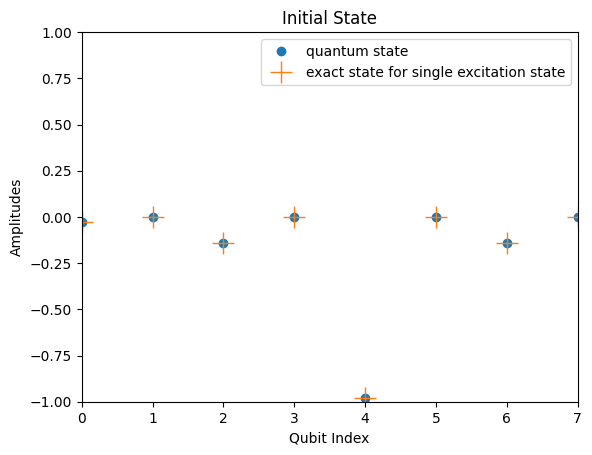

In [18]:
def quantum_solution_normalization(exact_amplitudes, df):
    qsol = get_quantum_amplitudes(df)
    global_phase = np.angle(np.vdot(qsol, exact_amplitudes))
    # Correct global phase and taking the real part
    qsol_corrected = np.real(np.exp(1j * global_phase) * qsol)

    return qsol_corrected


# Quantum amplitudes
quantum_amplitudes = get_quantum_amplitudes(df_state_check)

# Exact diagonalization
E0, V0 = np.linalg.eigh(h)
exact_ground_state = V0[:, 0] / np.linalg.norm(V0[:, 0])

quantum_amplitudes_corrected = quantum_solution_normalization(
    exact_ground_state, df_state_check
)
grid = np.arange(0, M)

plt.figure()
plt.title("Initial State")
plt.plot(grid, quantum_amplitudes_corrected, "o", label="quantum state")
plt.plot(
    grid,
    exact_ground_state,
    "+",
    markersize=16,
    label="exact state for single excitation state",
)
plt.xlim(0, M - 1)
plt.ylim(-1, 1)
plt.xlabel(r"Qubit Index")
plt.ylabel(r"Amplitudes")
plt.legend()
plt.show()

In [19]:
fidelity = np.abs(np.vdot(exact_ground_state, quantum_amplitudes)) ** 2
print(f"Fidelity of the initial state preparation: {fidelity:.3f}")
assert np.isclose(fidelity, 1.0, atol=TOLERANCE), "Fidelity is not close to 1"

Fidelity of the initial state preparation: 1.000


### General Quadratic Hamiltonian
In the general case the number of particles is not conserved under the dynamics of $H$ (Eq. (1)). In this case, the Hamiltonian can be written in a concise form

 $$ H =\sum_{\mu, \nu = 1}^M h_{\mu \nu}c_\mu^{\dagger} c_\nu + \frac{1}{2} \sum_{\mu,\nu} \Delta_{\mu\nu} c_\mu^\dagger c_\nu^{\dagger} + \text{h.c} ~~,$$

for numerical diagonalization it is convenient to introduce the **Majorana operators**:
 $$x_\mu = \frac{1}{\sqrt{2}}\left(c_\mu^\dagger + c_\mu \right)~~~,~~~p_\mu = \frac{i}{\sqrt{2}}\left(c_\mu^\dagger - c_\mu \right)~~, $$
  for $\mu=1,\dots ,M$.

 The Majorana operators satisfy the  anticommutation relations
$$
\{x_\mu,x_\nu \}= \{p_\mu,p_\nu \} = \delta_{\mu\nu}~~,~~\{x_\mu, p_\nu\} = 0 ~~.
$$ 


A unitary mapping relates between the two representations [[1]](#fermionic_gaussian_state)
$$ \mathbf{f} = \Omega \begin{pmatrix} \mathbf{c}^\dagger \\ \mathbf{c} \end{pmatrix}~~,~~~~~~ \Omega = \frac{1}{\sqrt{2}} \begin{pmatrix} \mathbb{I} & \mathbb{I} \\ i\mathbb{I} & -i\mathbb{I} \end{pmatrix}~~,$$
where $\mathbf{f} = (x_1,\cdots,x_M, p_1,\cdots p_{M})^T$.
Expressing the Hamiltonian in terms of the Majorana fermion operators, we have
$$ H = \frac{i}{2}\,\mathbf{f}^T A\, \mathbf{f} + \text{const}~~,$$
where $A$ is a $2M\times 2M$ real antisymmetric matrix.
$$ A = -i\,\Omega^* \begin{pmatrix} \Delta & h \\ -h^* & -\Delta^* \end{pmatrix} \Omega^\dagger~~.$$

Substituting into the Heisenberg equation, we obtain $$ \frac{d f_\eta}{dt} = i[H, f_\eta] = -\frac{1}{2} \sum_{\mu \nu} A_{\mu \nu}(-\delta_{\eta\mu}f_\nu + \delta_{\eta \nu}f_{\mu}) =  -\sum_{\mu}A_{\mu \eta}f_{\mu}~~, $$ where the last equality stems from $A$ being antisymmetric. This leads to a vector equation describing the Heisenberg dynamics of the Majorana operators $$\mathbf{f}(t) = e^{-tA}\mathbf{f}~~.  $$
Thus, the system dynamics under $H$, can be represented in terms of a simple linear relation, involving the Majorana operators.

To simplify the solution, we perform another basis transformation with the orthogonal matrix $R$, $\mathbf{f}' = R\mathbf{f}$, casting $A$ into its real Schur form: $$R AR^T =\begin{pmatrix} 0 & E \\ -E & 0 \end{pmatrix} ~~, $$ where $E = \text{diag}(\epsilon_1,\dots, \epsilon_M)$ is a diagonal matrix of size $M$ with positive increasing eigenvalues. The transformation splits the operators into two distinct pairs, where the dynamics of each pair of operators is decoupled from the rest. Finally, we transform back to fermionic operators

$$\begin{pmatrix} \mathbf{d}^\dagger \\ \mathbf{d} \end{pmatrix} = \Omega^\dagger \begin{pmatrix} \mathbf{f'}^{\dagger} \\ \mathbf{f'} \end{pmatrix} = \Omega^\dagger R \begin{pmatrix} \mathbf{f}^{\dagger} \\ \mathbf{f} \end{pmatrix} = \Omega^\dagger R \Omega \begin{pmatrix} \mathbf{c}^{\dagger} \\ \mathbf{c} \end{pmatrix} \equiv W \begin{pmatrix} \mathbf{c}^{\dagger} \\ \mathbf{c} \end{pmatrix}~~,$$
which is concisely expressed in terms of the unitary matrix $W = \Omega^\dagger R \Omega$, known as the Bogoliubov–de Gennes (BdG) matrix.
The operator basis transformation brings the Hamiltonian to the desired diagonal form 
$$ H = \sum_\eta \epsilon_{\eta}(d_\eta^\dagger d_\eta + d_\eta d_\eta^\dagger) + \text{const}~~.$$


The transformation matrix has a block form,
$$W=\begin{pmatrix} W_1^* & W_2^* \\ W_2 & W_1 \end{pmatrix} ~~,$$
therefore it suffices to treat only the lower half $W_L = (W_2 W_1)$. By applying Givens rotations on adjacent fermionic modes (encoded by the Jordan Wigner transformation) and particle-hole  Bogoliubov transformations on the last fermionic mode. 
The Givens rotation for the general case is given by the 4 by 4 matrix  
$$G^{(\text{gen})}_{ij}(\theta,\varphi) = \begin{pmatrix} G_{ij}(\theta,\varphi) & \mathbf{0} \\ \mathbf{0} & G_{ij}(\theta,-\varphi) \end{pmatrix}~~, $$
where the two mode Givens rotation $G_{ij}(\theta, \varphi)$ is defined in Eq. (4). 
The Bogoliubov transformation modifies only the last fermionic mode $c_M\rightarrow c_M^\dagger$, while the rest of the modes remain unchanged $c_j\rightarrow c_j$, for $j\in [1,M-1]$. In the qubit representation this corresponds to application of an $X$ gate on the last qubit.
We next introduce the matrix $U$, satisfying $VW_LU^\dagger = (\mathbf{0}~ \mathbf{1})$, where $V$ is an arbitrary unitary matrix. 
By employing a modified QR decomposition equation we can decompose $U$ into a sequence of $N_G = O(M^2)$ Givens and particle-hole transformations
$$U = B G_{N_G}\dots BG_1 B~~.$$

The corresponding gates can be performed in parallel leading to a circuit depth which is at most $2M-1$.
   





### Algorithmic Steps
The state preparation algorithm includes the following steps:
1. Constructs $A$
2. Evaluates transformation $R$, bringing $A$ to the real Schur form, and constructs BdG matrix, $W$.
3. Decomposes $U$ into a sequence of Givens rotations and particle-hole Bogoliubov transformations.

A simple example, utilizing only numpy data structures is presented in the technical notes section below. The example demonstrates the theoretical steps for the case of a $4$ by $4$ BdG matrix.
In the following section, we prepare the ground state of a general fermionic Hamiltonian (including particle non-conserving terms). 

### Preparation of a Fermionic Ground State

In [20]:
@qfunc
def prepare_fermionic_gaussian(
    h: list[list[float, n], n],
    Delta: list[list[float, n], n],
    qba: QArray[QBit, n],
) -> None:
    """
    Prepares the ground state of a general quadratic fermionic Hamiltonian
        H = sum_{mu,nu} c_mu^dagger h_{mu,nu} c_nu
            + (1/2) sum_{mu,nu} (Delta_{mu,nu} c_mu^dagger c_nu^dagger + h.c.),
    where h is hermitian and Delta is antisymmetric.

    The algorithm has three steps:
      (1) build the dynamical generator A in the Majorana basis,
      (2) bring A to its canonical Schur form [[0, E], [-E, 0]] via an
          orthogonal transformation R, and assemble the Bogoliubov-de Gennes
          matrix W = Omega^dagger R Omega; the lower half W_L = (W_2, W_1) is
          the input to the decomposition routine,
      (3) decompose conj(W_L) (matching openfermion's
          gaussian_state_preparation_circuit convention) into Givens
          rotations and particle-hole transformations on the last fermionic
          mode and apply the resulting gates in reverse order to the
          c-vacuum |0^n>. The 'pht' marker becomes an X on qubit n-1, and
          each Givens tuple becomes a `phased_givens` gate.

    Args:
        h (ndarray): hermitian one-body matrix (n x n).
        Delta (ndarray): antisymmetric pairing matrix (n x n).
        qba (QArray[QBit, n]): qubit register, taken to start in |0^n>.
    """
    # Promote to numpy arrays — Classiq passes the matrices in as nested
    # Python lists, which np.block can't consume alongside conjugated arrays.
    h_arr = np.asarray(h, dtype=complex)
    Delta_arr = np.asarray(Delta, dtype=complex)

    # 1. Build the real antisymmetric generator A in the Majorana basis.
    Im_n = np.eye(n)
    Omega_n = (1 / np.sqrt(2)) * np.block([[Im_n, Im_n], [1j * Im_n, -1j * Im_n]])
    H_BdG = np.block([[Delta_arr, h_arr], [-h_arr.conj(), -Delta_arr.conj()]])
    A = np.real(-1j * Omega_n.conj() @ H_BdG @ Omega_n.conj().T)

    # 2. Real Schur decomposition and permutation to canonical form
    #    [[0, E], [-E, 0]] with non-negative diagonal of E.
    _, Z_schur = scipy.linalg.schur(A, output="real")
    P = np.zeros((2 * n, 2 * n))
    for k in range(n):
        P[k, 2 * k] = 1.0
        P[n + k, 2 * k + 1] = 1.0
    R = P @ Z_schur.T
    T_canonical = R @ A @ R.T
    b = np.diag(T_canonical[:n, n:])
    signs = np.where(b >= 0, 1.0, -1.0)
    R = np.diag(np.concatenate([np.ones(n), signs])) @ R

    # 3. Bogoliubov-de Gennes matrix W and its lower half W_L = (W_2, W_1).
    W = Omega_n.conj().T @ R @ Omega_n
    W_L = W[n:, :]

    # 4. Decompose conj(W_L) into Givens rotations + particle-hole
    #    transformations and apply the gates in reverse order to |0^n>.
    decomposition, _, _, _ = fermionic_gaussian_decomposition(W_L.conj())
    circuit_description = list(reversed(decomposition))
    for parallel_ops in circuit_description:
        for op in parallel_ops:
            if op == "pht":
                X(qba[n - 1])
            else:
                i, j, theta, phi = op
                phased_givens(theta, phi, [qba[i], qba[j]])

For two fermionic modes the full Fock space is only $4$-dimensional, so we can compare the prepared state directly to the analytical ground state of $H$ obtained by exact diagonalization.

We first evaluate the analytical result by building the $4$ by $4$ Hamiltonian matrix, diagonalizing it, and picking the lowest-energy eigenvector as the analytical ground state.

The Hamiltonian is defined by the following matrices:

In [ ]:
# Hermitian one-body matrix h (n = 2 fermionic modes)
h = np.array(
    [
        [1.0, 0.5],
        [0.5, -0.5],
    ],
    dtype=complex,
)

# Antisymmetric pairing matrix Delta
delta = 0.3
Delta = np.array(
    [
        [0.0, delta],
        [-delta, 0.0],
    ],
    dtype=complex,
)

In [21]:
# Build the full Fock-space Hamiltonian directly via Jordan-Wigner.
#
# Convention: qubit i = mode i, with np.kron placing qubit 0 in the least
# significant bit. This matches Classiq's bitstring convention, so no extra
# basis reordering is needed when comparing against the simulator output.
I2 = np.eye(2, dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
Sp = np.array([[0, 0], [1, 0]], dtype=complex)  # sigma+ = c^dagger on a single mode
n = 2  # number of fermionic modes


def c_dag(j: int, n_modes: int) -> np.ndarray:
    """Jordan-Wigner image of the creation operator c_j^dagger on mode j."""
    op = np.array([[1.0]], dtype=complex)
    for k in range(n_modes - 1, -1, -1):
        if k > j:
            factor = I2
        elif k == j:
            factor = Sp
        else:  # k < j picks up a Z from the JW string
            factor = Z
        op = np.kron(op, factor)
    return op


# Assemble H = sum_{mu nu} h_{mu nu} c_mu^dag c_nu
#              + (1/2) sum_{mu nu} (Delta_{mu nu} c_mu^dag c_nu^dag + h.c.)
c_dags = [c_dag(j, n) for j in range(n)]
cs = [op.conj().T for op in c_dags]
H_full = np.zeros((2**n, 2**n), dtype=complex)
for mu in range(n):
    for nu in range(n):
        H_full += h[mu, nu] * c_dags[mu] @ cs[nu]
        H_full += 0.5 * Delta[mu, nu] * c_dags[mu] @ c_dags[nu]
        H_full += 0.5 * np.conj(Delta[mu, nu]) * cs[nu] @ cs[mu]

# 2. Diagonalize and pick the lowest-energy eigenvector.
energies_full, vecs_full = np.linalg.eigh(H_full)
analytical_gs = vecs_full[:, 0]
print(f"Full-space eigenvalues:   {np.round(energies_full, 6)}")
print(f"Analytical ground state:  {np.round(analytical_gs, 6)}")

NameError: name 'Delta' is not defined


Next, we synthesize a 2-qubit circuit that employs `prepare_fermionic_gaussian` to prepare the ground state, the amplitudes match up to a global phase.

In [ ]:
@qfunc
def main(qba: Output[QArray[QBit, n]]) -> None:
    allocate(n, qba)
    prepare_fermionic_gaussian(h, Delta, qba)

Now we execute on the statevector simulator, and compute the fidelity.


In [ ]:
qprog_check = synthesize(main)
df_check = calculate_state_vector(qprog_check)

# Pull amplitudes out of the dataframe (already in Classiq's qubit-i = bit-i
# convention).
mask_check = np.abs(df_check["amplitude"]) > 1e-12
quantum_amps = np.zeros(2**n, dtype=complex)
for _, row in df_check.loc[mask_check].iterrows():
    quantum_amps[int(row["bitstring"], 2)] = row["amplitude"]
quantum_amps = quantum_amps / np.linalg.norm(quantum_amps)

fidelity = np.abs(np.vdot(analytical_gs, quantum_amps)) ** 2
print(f"\nFidelity vs analytical ground state: {fidelity:.1f}")
assert np.isclose(fidelity, 1.0, atol=TOLERANCE), "Fidelity is not close to 1"


Fidelity vs analytical ground state: 1.0


## Technical Notes

### Heisenberg dynamics of the Dirac operators under a number-conserving quadratic Hamiltonian

Referenced from the *Preparation of a Slater Determinant State* section. We show why diagonalizing the $M\times M$ one-body matrix $h$ is enough to capture the dynamics generated by $H$ in the full $2^M$-dimensional Fock space.

Using the anti-commutation relations and the Heisenberg equation ($\frac{dO(t)}{dt} = i\left[H, O(t) \right]$), we have 

$$\frac{dc_\lambda^\dagger}{dt} = i\left[H, c_\lambda^\dagger \right]= i \sum_{\mu\nu} h_{\mu\nu}[c_\mu^\dagger c_\nu,c_\lambda] $$


$$= i \sum_{\mu\nu} h_{\mu\nu}[c_\mu^\dagger c_\nu,c_\lambda^\dagger] = i \sum_{\mu\nu} h_{\mu\nu}c_\mu^\dagger \delta_{\nu \lambda} = i \sum_{\mu} h_{\mu\lambda}c_\mu^\dagger  ~~, $$
where the time-dependence is suppressed for conciseness.

The dynamics in the Heisenberg representation can therefore be expressed as $$\mathbf{c}^\dagger (t) = e^{i H t} \mathbf{c}^\dagger e^{-i H t}  = e^{i h^T }\mathbf{c}^\dagger~~,$$ where $\mathbf{c}^\dagger = \{c_1^\dagger,\dots,c_M^\dagger\}^T$ and $M$ is the total number of fermionic modes. Remarkably, this implies that the diagonalization of $h$, (an $M$ by $M$ matrix) provides the dynamics in the $2^M$ Hilbert space.


### Simple Example for a General Hamiltonian (Particle non-Conserving)
We consider a quadratic Hamiltonian of the form
$$ H = \sum_{\mu \nu} c_\mu^\dagger h_{\mu \nu} c_{\nu} + \frac{1}{2}\sum_{\mu \nu}\Delta_{\mu \nu}\left(c_\mu^\dagger c_\nu^\dagger +\text{h.c} \right)~~,$$
Two $2$ by $2$ matrices, $h$ and $\Delta$, are considered, where $h$ is hermitian and $\Delta$ is antisymmetric, corresponding to one-body terms in the Hamiltonian.
Following, we construct the matrix $A$, associated with the Majorana fermion representation of the Hamiltonian, evaluate the BdG matrix $W$, decompose it into Givens rotations and Bogoliubov transformations and verify the decomposition.

In [ ]:
# Hermitian one-body matrix h (n = 2 fermionic modes)
h = np.array(
    [
        [1.0, 0.5],
        [0.5, -0.5],
    ],
    dtype=complex,
)

# Antisymmetric pairing matrix Delta
delta = 0.3
Delta = np.array(
    [
        [0.0, delta],
        [-delta, 0.0],
    ],
    dtype=complex,
)

# Bogoliubov-de Gennes (BdG) matrix in the Dirac basis (\{\vec{c}^dagger,\vec{c}\}^T)
H_BdG = np.block(
    [
        [Delta, h],
        [-h.conj(), -Delta.conj()],
    ]
)

n = h.shape[0]

# Unitary mapping between Dirac and Majorana representations
Im = np.eye(n)
Omega = (1 / np.sqrt(2)) * np.block(
    [
        [Im, Im],
        [1j * Im, -1j * Im],
    ]
)

# Real antisymmetric generator A in the Majorana representation
A = -1j * Omega.conj() @ H_BdG @ Omega.conj().T
A = np.real(A)
assert np.allclose(A, -A.T, atol=TOLERANCE)
print(f"A matrix:\n {A}\n")
# Real Schur decomposition: A = Z T Z^T, where T is with 2x2 blocks [[0, b_k], [-b_k, 0]]
T_schur, Z = scipy.linalg.schur(A, output="real")
assert np.allclose(A, Z @ T_schur @ np.transpose(Z), atol=TOLERANCE)


# Permute to bring the canonical Schur form to [[0, E], [-E, 0]]
P = np.zeros((2 * n, 2 * n))
for k in range(n):
    P[k, 2 * k] = 1.0
    P[n + k, 2 * k + 1] = 1.0

R = P @ Z.T
S = R @ A @ R.T
print(f"R * A * R^T = [[0,E],[-E,0]]:\n {np.round(S, 3)}")

# BdG transformation matrix
W = Omega.conj().T @ R @ Omega
assert np.allclose(
    W @ W.conj().T, np.eye(2 * n), atol=TOLERANCE
)  # verifies unitarity of W


W_L = W[
    n:, :
]  # an n by 2n matrix, which is decomposed into Givens rotations and spin-hole Bogoliubov transformations

A matrix:
 [[ 0.   0.   1.   0.2]
 [ 0.   0.   0.8 -0.5]
 [-1.  -0.8  0.   0. ]
 [-0.2  0.5  0.   0. ]]

R * A * R^T = [[0,E],[-E,0]]:
 [[ 0.    -0.     1.292  0.   ]
 [ 0.    -0.    -0.     0.511]
 [-1.292  0.     0.    -0.   ]
 [-0.    -0.511  0.     0.   ]]


We utilize `OpenFermion`'s `fermionic_gaussian_decomposition` method which receives the lower half of $W$, and outputs four objects describing the canonical decomposition

$$ V\, W_L\, U^\dagger = (\mathbf{0}\;\; D)~~, $$

where $V$ is an $M\times M$ unitary, $U$ is a $2M\times 2M$ unitary, and $D$ is an $M\times M$ diagonal matrix of unit-modulus phases, where $M$ is the number of fermionic modes.

- `decomposition`: the description of $U$ as a sequence of two-mode operations applied to the columns of $W_L$. The list groups operations into layers that can be performed in parallel. Each layer entry is either the string `'pht'`, indicating a particle-hole Bogoliubov transformation on the last fermionic mode, or a tuple specifying a "double" Givens rotation on adjacent fermionic modes, acting on the upper $M$ columns of $W_L$ and as its complex conjugate on the lower $M$ columns.
- `left_decomposition` and `left_diagonal`: are utilized to compose auxiliary $M\times M$ unitary $V^T D^*$
- `diagonal`: a length-$M$ array of unit-modulus complex numbers — the diagonal entries of $D$ in the identity above. It is utilized to evaluate $V=D D^\dagger V$.

In the next cell we use these four outputs to reconstruct both $U$ and $V$ explicitly and check the identity $V W_L U^\dagger = (\mathbf{0}\;\; D)$ holds.

In [ ]:
decomposition, left_decomposition, diagonal, left_diagonal = (
    fermionic_gaussian_decomposition(W_L)
)


def build_U_from_decomposition_gen(n: int, decomposition) -> np.ndarray:
    """
    Reconstruct the 2n x 2n unitary U from openfermion's `decomposition` (the
    column-side Givens rotations and particle-hole transformations), satisfying
    V @ W_L @ U^dagger = (0, D).

    Each Givens entry (j, j+1, theta, phi) is a "double Givens" that acts on
    columns (j, j+1) of the upper half with G(theta, phi) and on columns
    (j, j+1) of the lower half with G(theta, phi).conj(). Each 'pht' marker is
    a column swap of (n-1, 2n-1).
    """
    Udag = np.eye(2 * n, dtype=complex)
    for parallel_ops in decomposition:
        for op in parallel_ops:
            if op == "pht":
                swap_columns(Udag, n - 1, 2 * n - 1)
            else:
                j, jp1, theta, phi = op
                c, s, e = np.cos(theta), np.sin(theta), np.exp(1j * phi)
                G = np.array([[c, -e * s], [s, e * c]], dtype=complex)
                double_givens_rotate(Udag, G, j, jp1, which="col")
    # Applying the same column ops to the identity yields U^dagger.
    return Udag.conj().T


def build_V_from_decomposition_gen(
    n: int, left_decomposition, left_diagonal, diagonal
) -> np.ndarray:
    """
    Reconstruct the n x n unitary V from openfermion's `left_decomposition`
    (the Givens decomposition of left_unitary^T @ diag(diagonal*)) and the two
    diagonals.

    openfermion's givens_decomposition_square gives
        left_unitary.T @ diag(diagonal*) = diag(left_diagonal) @ U_left,
    so V = left_unitary = diag(diagonal) @ U_left^T @ diag(left_diagonal).
    """
    T = np.eye(n, dtype=complex)
    for parallel_ops in left_decomposition:
        for j, jp1, theta, phi in parallel_ops:
            c, s, e = np.cos(theta), np.sin(theta), np.exp(1j * phi)
            G = np.array([[c, -e * s], [s, e * c]], dtype=complex)
            givens_rotate(T, G, j, jp1, which="col")
    # Applying the same column ops to the identity yields U_left^dagger.
    U_left = T.conj().T
    return np.diag(diagonal) @ U_left.T @ np.diag(left_diagonal)


U = build_U_from_decomposition_gen(n, decomposition)
V = build_V_from_decomposition_gen(n, left_decomposition, left_diagonal, diagonal)

# verifying the decomposition: V W_L U^dagger = [0, D]
target = np.zeros((n, 2 * n), dtype=complex)
target[range(n), range(n, 2 * n)] = diagonal
assert np.allclose(V @ W_L @ U.conj().T, target, atol=TOLERANCE)

## References
<a id='fermionic_gaussian_state'>[1] </a>: Jiang, Z., Sung, K. J., Kechedzhi, K., Smelyanskiy, V. N., & Boixo, S. (2018). Quantum algorithms to simulate many-body physics of correlated fermions. Physical Review Applied, 9(4), 044036. [arXiv:1711.05395](https://arxiv.org/abs/1711.05395).

<a id='google_paper'>[2] </a>: Arute, F., Arya, K., Babbush, R., Bacon, D., Bardin, J. C., Barends, R., ... & Zanker, S. (2020). Observation of separated dynamics of charge and spin in the Fermi-Hubbard model. [arXiv:2010.07965](https://arxiv.org/abs/2010.07965).

<a id='numerical'>[3] </a>:Surace, J., & Tagliacozzo, L. (2022). Fermionic Gaussian states: an introduction to numerical approaches. SciPost Physics Lecture Notes, 054. [arXiv:2111.08343](https://arxiv.org/abs/2111.08343).




